# Internet research 

## Scope

https://www.siglent.eu/product/13555727/siglent-sds814x-hd-4ch-100mhz-12bit-oscilloscope

https://ktln2.org/2018/02/20/control-siglent-oscilloscope/

https://siglentna.com/application-note/programming-example-sds-oscilloscope-screen-capture-python/

## WFG 

https://www.siglent.eu/product/1136898/siglent-sdg1032x-30mhz-function-arbitrary-waveform-generator

https://github.com/tspspi/pysdg1032x

# Pyvisa

https://pyvisa.readthedocs.io/en/latest/

# Logbook 

My google logbook from testing:

[Control software - Google Docs](https://docs.google.com/document/d/1KSsfIMDRvzPyhMPeLPiSNMyzb4p_WQA87ZNAqpBZxXU/edit?tab=t.0)

# Interfacing them

In [1]:
import pyvisa
rm = pyvisa.ResourceManager()

In [2]:
rm.list_resources()

('ASRL1::INSTR',
 'ASRL2::INSTR',
 'ASRL3::INSTR',
 'ASRL4::INSTR',
 'USB0::0xF4EC::0x1103::SDG1XDDQ802940::INSTR',
 'USB0::0xF4EC::0x1017::SDS08A0Q808362::INSTR')

In [3]:
rm.visalib

<IVIVisaLibrary('/Library/Frameworks/visa.framework/visa')>

In [4]:
def get_instrument(rm, keyword):
    instrument = None
    resource_list = rm.list_resources()
    for r in resource_list:
        if keyword in r:
            instrument = rm.open_resource(r)
            break
    return instrument

In [5]:
scope = get_instrument(rm, "SDS")
scope.query("*IDN?")

'Siglent Technologies,SDS814X HD,SDS08A0Q808362,3.8.12.1.1.3.8\n'

In [6]:
wfgen = get_instrument(rm, "SDG")
wfgen.query("*IDN?")

'Siglent Technologies,SDG1032X,SDG1XDDQ802940,1.01.01.33R8\n'

Awesome, working!

# Grabbing stuff from the scope

### A screenshot 

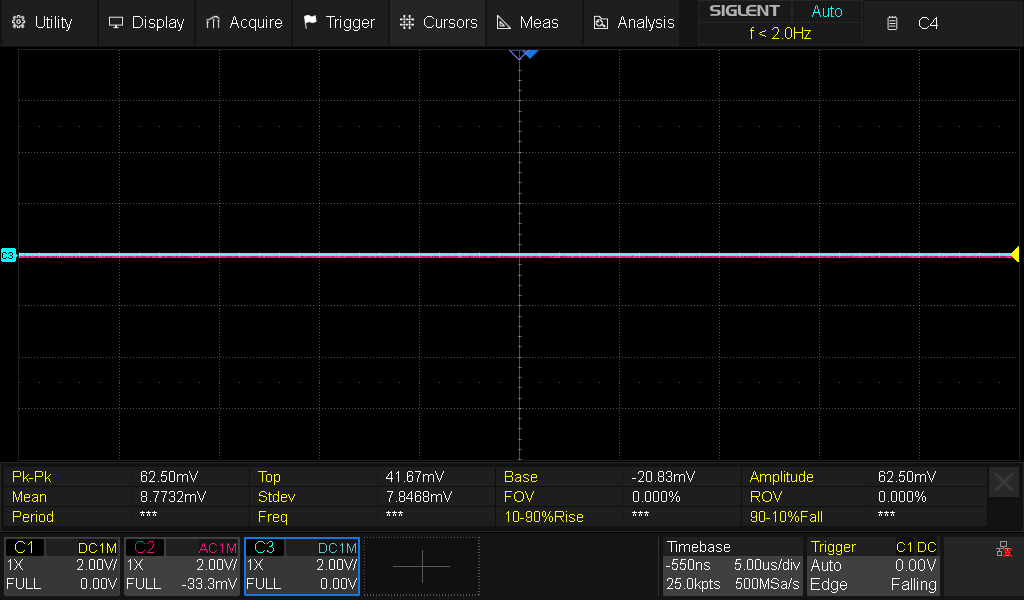

In [7]:
from IPython.display import Image
scope.write("PRIN? PNG")
data = scope.read_raw()
Image(data)

In [19]:
help(scope.read_raw)

Help on method read_raw in module pyvisa.resources.messagebased:

read_raw(size: Optional[int] = None) -> bytes method of pyvisa.resources.usb.USBInstrument instance
    Read the unmodified string sent from the instrument to the computer.

    In contrast to read(), no termination characters are stripped.

    Parameters
    ----------
    size : Optional[int], optional
        The chunk size to use to perform the reading. Defaults to None,
        meaning the resource wide set value is set.

    Returns
    -------
    bytes
        Bytes read from the instrument.

